# General hint
1) For the data analysis below the python module 'pandas' is used as it (typically) provides a readable and understandable possibility to deal with data. Note that there might be many different ways to reach the same analysis goal. For introductory purposes readability is most important here but not necessarily performance. 

2) In order the check the right paths, just run the whole notebook (Run all cells) -- this should not result in any errors.

# Introduction
The dataset used in this notebook is from the HPC cluster 'Taurus' at TU Dresden. The data contains sensor data about the temperature [°C] and power consumption [W] over time of a selection of compute nodes, esp. from the island 'haswell' within a time span from May-November 2016. The full island contains approx. 1500 nodes, whereby every node contains two CPUs. There are two nodes collected on a so called blade which has its own cooling circuit. 
The following image shows a so called blade with its cooling circuit. 

<img src="blade-taurus.png" width="400" height="300" />

In this notebook a couple of nodes/CPUs from the larger dataset is analyzed with descriptive statistics.

# Data Intro
Get some basic information about the new instance of a dataframe. Use therefore the method 'info' of the dataframe class in pandas. See the docs at https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html

In [181]:
import pandas as pd

In [182]:
# maybe you need to set this path properly
taurusdata = pd.read_csv('watts-temp-merged.csv')

In [183]:
taurusdata.info()

<class 'pandas.DataFrame'>
RangeIndex: 302852 entries, 0 to 302851
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   node       302852 non-null  str    
 1   cpu        302852 non-null  str    
 2   timestamp  302852 non-null  str    
 3   temp       302852 non-null  int64  
 4   watts      302174 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 11.6 MB


Get a first insight into the data. Use therefore the method 'head' of the dataframe class in pandas. See the docs at https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html
Note that 'node' and 'cpu' are simple categorical variables for distinction. The temperature is measured in [°C] and the power consumption ('watts') in [W].

In [184]:
taurusdata.head()

,node,cpu,timestamp,temp,watts
0,taurusi6086,cpu0,2016-04-25 12:41:11,63,10.749997
1,taurusi6086,cpu0,2016-04-25 12:41:15,64,11.124858
2,taurusi6086,cpu0,2016-04-25 12:41:20,63,11.334210
3,taurusi6086,cpu0,2016-04-25 12:41:25,64,10.725058
4,taurusi6086,cpu0,2016-04-25 12:41:30,63,10.762389


# Analysis Part 1 -- Single Node
In this part of the analysis we will work with the data of a single CPU only. Here we choose taurusdata['node'] == 'taurusi6344' and taurusdata['cpu'] == 'cpu1'

In [185]:
singlecpu = taurusdata.loc[(taurusdata['node'] == 'taurusi6344') & (taurusdata['cpu'] == 'cpu1')]

In [186]:
taurusdata[(taurusdata['node'] == 'taurusi6344') & (taurusdata['cpu'] == 'cpu1')]

,node,cpu,timestamp,temp,watts
225026,taurusi6344,cpu1,2016-04-25 12:41:11,53,6.775252
225027,taurusi6344,cpu1,2016-04-25 12:41:15,53,6.624771
225028,taurusi6344,cpu1,2016-04-25 12:41:20,53,7.261403
225029,taurusi6344,cpu1,2016-04-25 12:41:25,53,8.562519
225030,taurusi6344,cpu1,2016-04-25 12:41:30,53,7.021208
...,...,...,...,...,...
250508,taurusi6344,cpu1,2016-11-05 08:43:37,65,6.746433
250509,taurusi6344,cpu1,2016-11-05 08:48:36,79,29.492789
250510,taurusi6344,cpu1,2016-11-05 08:53:35,66,8.019001
250511,taurusi6344,cpu1,2016-11-05 08:58:34,82,87.455445


In [187]:
taurusdata.iloc[2]

node                 taurusi6086
cpu                         cpu0
timestamp    2016-04-25 12:41:20
temp                          63
watts                   11.33421
Name: 2, dtype: object

## Todo
1) Calculate the basic descriptive statistics for 'temp' and 'watts', namely: mean, standard deviation, mininmum, maximum, all quartiles (i.e. quantiles with level 25%, 50%, 75%). 

Hint: Use the method 'describe' of pandas dataframe, see the docs at https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html

2) Do you see some indication for extreme values? Explain your observation with statistical measures!

               temp         watts
count  25487.000000  25457.000000
mean      74.649154     62.171613
std       13.081534     45.525440
min       48.000000      4.528585
25%       64.000000      7.363638
50%       77.000000     88.820081
75%       86.000000    102.456565
max       95.000000    133.179479


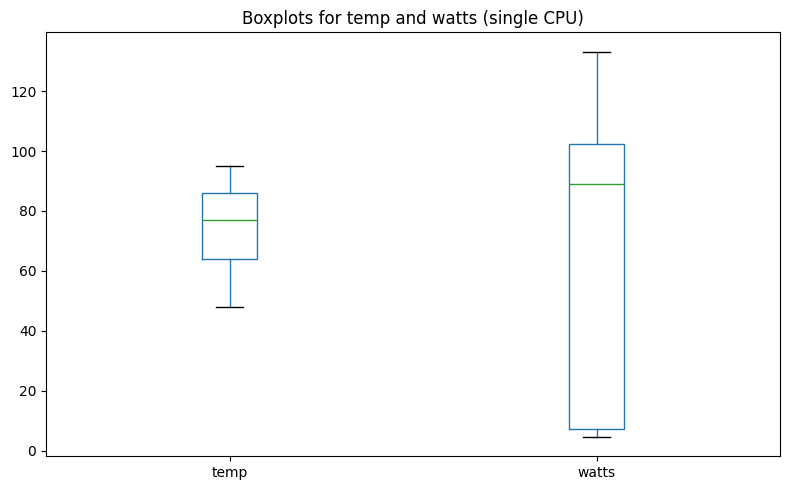

In [188]:
import matplotlib.pyplot as plt
stats = singlecpu[['temp', 'watts']].describe()
print(stats)
ax = singlecpu[['temp', 'watts']].boxplot(figsize=(8, 5), grid=False)
ax.set_title('Boxplots for temp and watts (single CPU)')
plt.tight_layout()
plt.show()


In [189]:
singlecpu

,node,cpu,timestamp,temp,watts
225026,taurusi6344,cpu1,2016-04-25 12:41:11,53,6.775252
225027,taurusi6344,cpu1,2016-04-25 12:41:15,53,6.624771
225028,taurusi6344,cpu1,2016-04-25 12:41:20,53,7.261403
225029,taurusi6344,cpu1,2016-04-25 12:41:25,53,8.562519
225030,taurusi6344,cpu1,2016-04-25 12:41:30,53,7.021208
...,...,...,...,...,...
250508,taurusi6344,cpu1,2016-11-05 08:43:37,65,6.746433
250509,taurusi6344,cpu1,2016-11-05 08:48:36,79,29.492789
250510,taurusi6344,cpu1,2016-11-05 08:53:35,66,8.019001
250511,taurusi6344,cpu1,2016-11-05 08:58:34,82,87.455445


In [190]:
singlecpu.describe()

,temp,watts
count,25487.000000,25457.000000
mean,74.649154,62.171613
std,13.081534,45.525440
min,48.000000,4.528585
25%,64.000000,7.363638
50%,77.000000,88.820081
75%,86.000000,102.456565
max,95.000000,133.179479


In [191]:
taurusdata.describe()

,temp,watts
count,302852.000000,302174.000000
mean,68.075037,50.096561
std,13.217962,41.780829
min,-32.000000,1.074336
25%,56.000000,10.061684
50%,68.000000,35.274721
75%,77.000000,93.454630
max,96.000000,133.249055


In [192]:
singlecpu['temp'].quantile(q = 0.75)

np.float64(86.0)

In [193]:
taurusdata.quantile(q = 0.75, numeric_only=True)

temp     77.00000
watts    93.45463
Name: 0.75, dtype: float64

In [194]:
taurusdata.info()

<class 'pandas.DataFrame'>
RangeIndex: 302852 entries, 0 to 302851
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   node       302852 non-null  str    
 1   cpu        302852 non-null  str    
 2   timestamp  302852 non-null  str    
 3   temp       302852 non-null  int64  
 4   watts      302174 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 11.6 MB


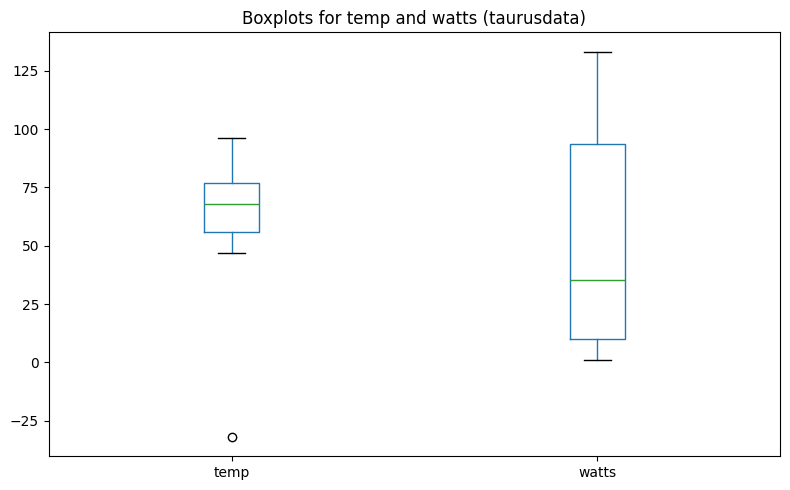

In [195]:
taurusdata.boxplot(column=['temp', 'watts'], figsize=(8, 5), grid=False)
plt.title('Boxplots for temp and watts (taurusdata)')
plt.tight_layout()
plt.show()

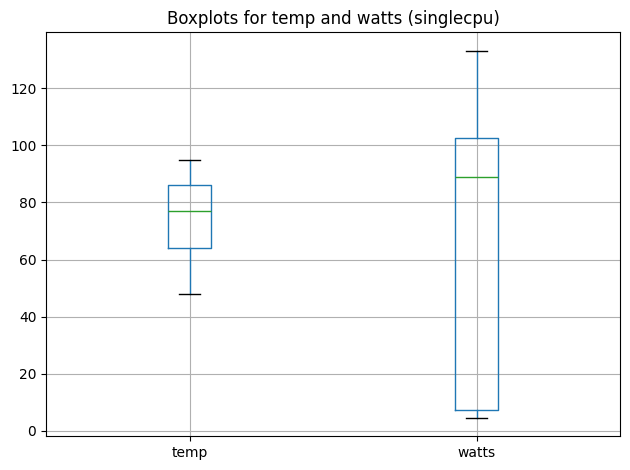

In [196]:
singlecpu.boxplot()
plt.title('Boxplots for temp and watts (singlecpu)')
plt.tight_layout()
plt.show()

## Todo
Visualize the quartiles for 'temp' and 'watts' by creating a boxplot. 

Hint: Use the method 'boxplot' of pandas dataframe, see the docs at https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html

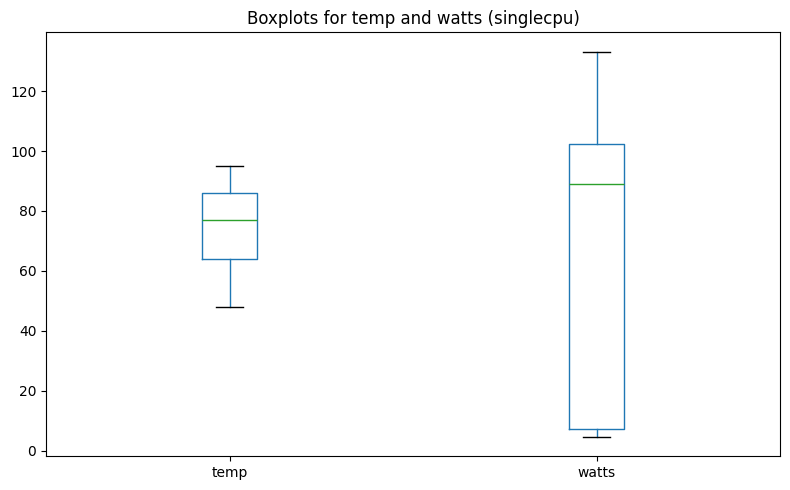

In [197]:
# boxplots for 'temp' and 'watts'
singlecpu.boxplot(column=['temp', 'watts'], figsize=(8, 5), grid=False)
plt.title('Boxplots for temp and watts (singlecpu)')
plt.tight_layout()
plt.show()

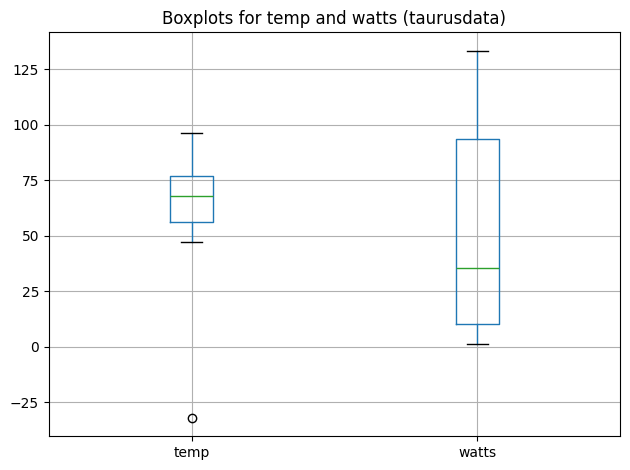

In [198]:
taurusdata.boxplot()
plt.title('Boxplots for temp and watts (taurusdata)')
plt.tight_layout()
plt.show()

## Todo 
Create the histograms for 'temp' and 'watts' each. Play around with the number of bins and observe the impression of the corresponding histograms. 

Hint 1: Use the method 'plot.hist' of the pandas dataframe class, see the docs at https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.hist.html

Hint 2: In order to handle overplotting use the parameter, e.g. 'alpha = 0.5'

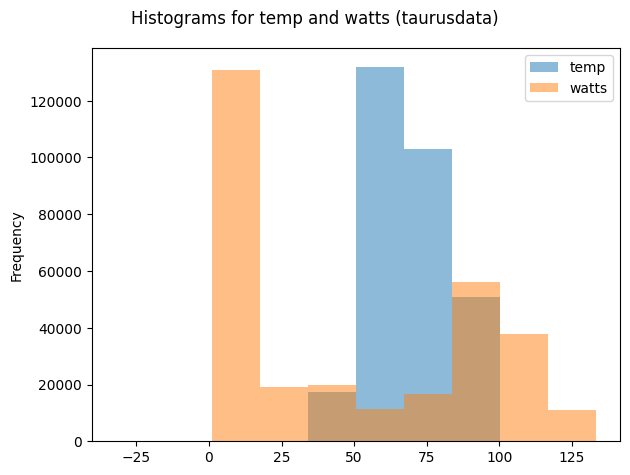

In [199]:
taurusdata.plot.hist(alpha=0.5)
plt.suptitle('Histograms for temp and watts (taurusdata)')
plt.tight_layout()
plt.show()

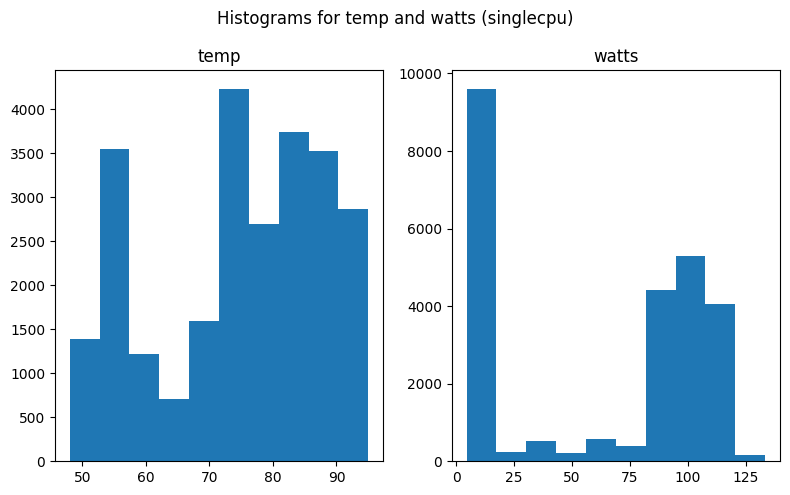

In [200]:
# histograms for 'temp' and 'watts'
singlecpu[['temp', 'watts']].hist(figsize=(8, 5), grid=False)
plt.suptitle('Histograms for temp and watts (singlecpu)')
plt.tight_layout()
plt.show()

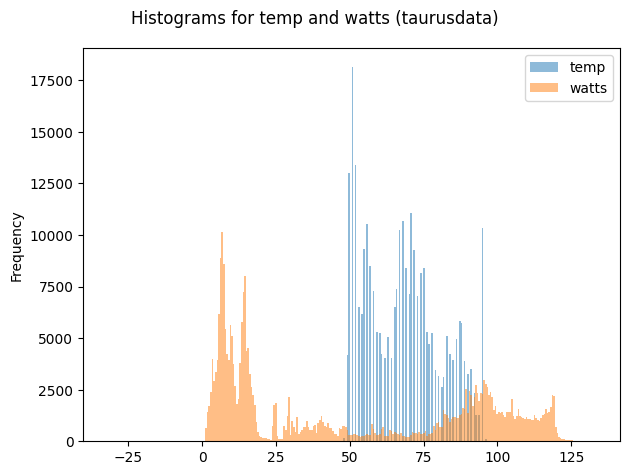

In [201]:
taurusdata.plot.hist(alpha=0.5, bins=300)
plt.suptitle('Histograms for temp and watts (taurusdata)')
plt.tight_layout()
plt.show()

## Todo 
1 ) Create the (univariate) kernel density for 'temp' and 'watts' each. Play around with the bandwith parameter and observe the impression of the corresponding graphs. 

Hint: Use the method 'plot.kde' of the pandas dataframe class, see the docs at https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.kde.html

2) Compare the kernel density estimates with the histograms. Use the parameter 'xlim' while plotting to get similar scaling esp. on the x-axis. Think about where to get the limit values.

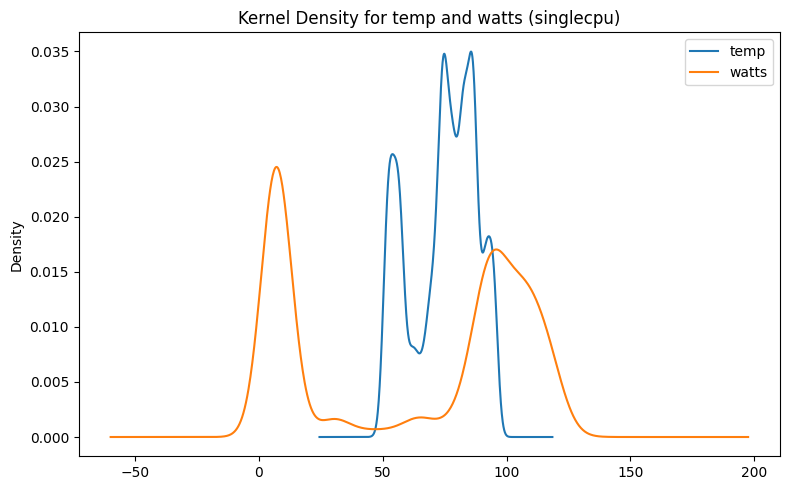

In [202]:
# (univariate) kernel density for 'temp' and 'watts'
import numpy as np
import scipy
singlecpu[['temp', 'watts']].plot.kde(figsize=(8, 5))
plt.title('Kernel Density for temp and watts (singlecpu)')
plt.tight_layout()
plt.show()

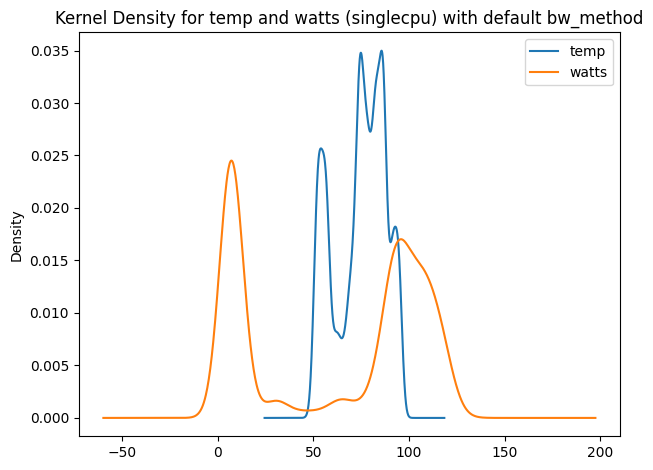

In [203]:
singlecpu.plot.kde()
plt.title('Kernel Density for temp and watts (singlecpu) with default bw_method')
plt.tight_layout()
plt.show()

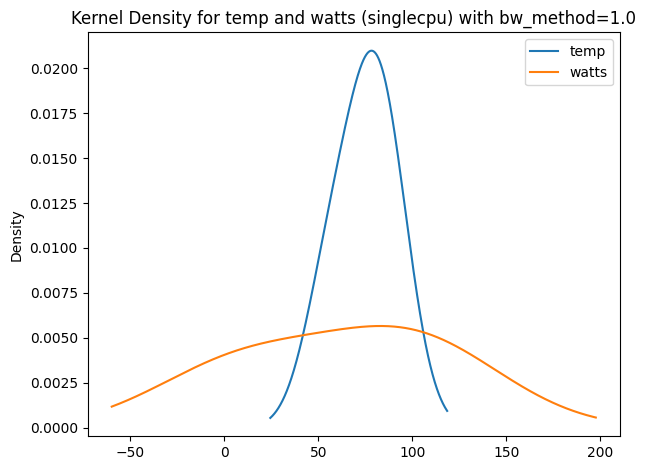

In [204]:
singlecpu.plot.kde(bw_method=1.0)
plt.title('Kernel Density for temp and watts (singlecpu) with bw_method=1.0')
plt.tight_layout()
plt.show()

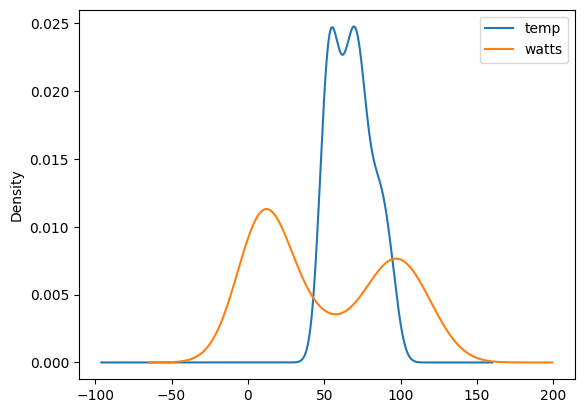

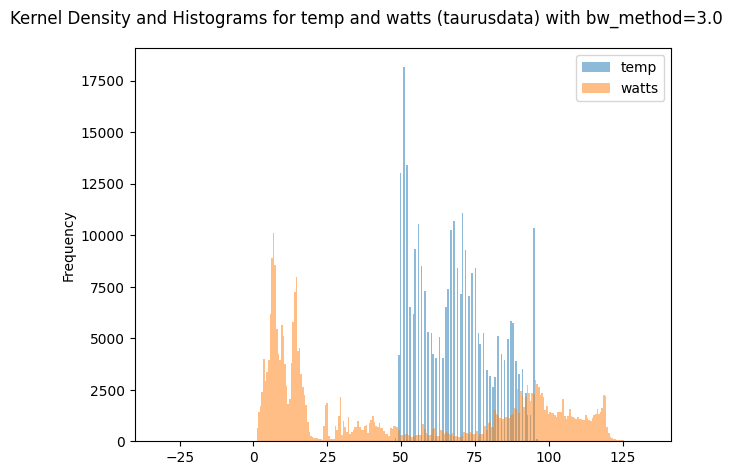

In [205]:
taurusdata.plot.kde(bw_method=0.4)
taurusdata.plot.hist(alpha=0.5, bins=300)
plt.suptitle('Kernel Density and Histograms for temp and watts (taurusdata) with bw_method=3.0')
plt.tight_layout()
plt.show()

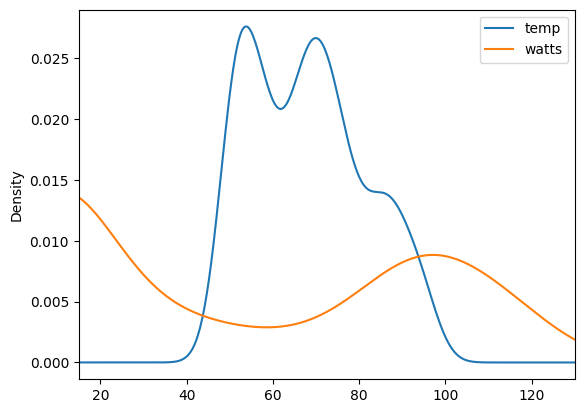

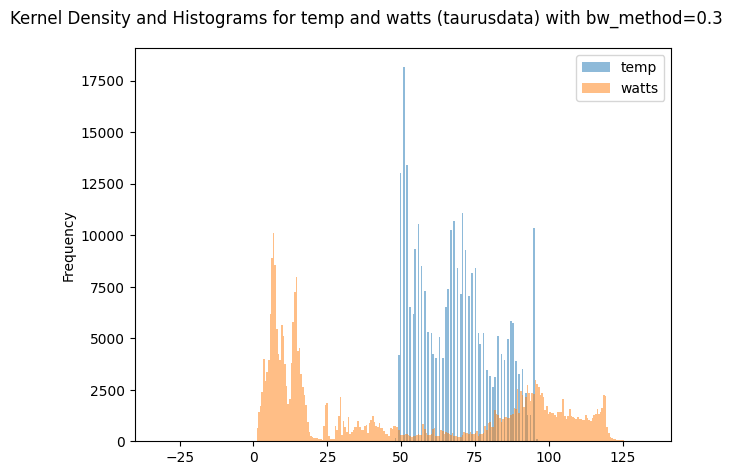

In [206]:
taurusdata.plot.kde(bw_method=0.3, xlim=(15, 130))
taurusdata.plot.hist(alpha=0.5, bins=300)
plt.suptitle('Kernel Density and Histograms for temp and watts (taurusdata) with bw_method=0.3')
plt.tight_layout()
plt.show()

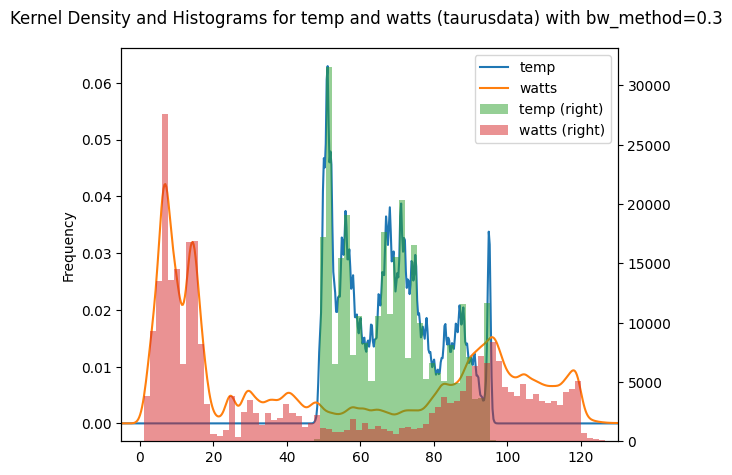

In [207]:
ax = taurusdata.plot.kde( bw_method=0.03, xlim=(-5, 130))
taurusdata.plot.hist(alpha=0.5, bins=100, xlim=(-5, 130), ax=ax, secondary_y=True)
plt.suptitle('Kernel Density and Histograms for temp and watts (taurusdata) with bw_method=0.3')
plt.tight_layout()
plt.show()

## Todo 
Create a plot for 'temp' and 'watts' over time (both variables into one plot). Observe the interplay between the temperature and power consumption. 

Hint 1: Use the method 'plot' of the pandas dataframe class, see the docs at https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html

Hint 2a: If necessary, enlarge the plot size by using the parameter 'figsize'.

Hint 2b: In order to handle overplotting use the parameter, e.g. 'alpha = 0.5'

In [215]:
singlecpu.head(10)

,node,cpu,timestamp,temp,watts
225026,taurusi6344,cpu1,2016-04-25 12:41:11,53,6.775252
225027,taurusi6344,cpu1,2016-04-25 12:41:15,53,6.624771
225028,taurusi6344,cpu1,2016-04-25 12:41:20,53,7.261403
225029,taurusi6344,cpu1,2016-04-25 12:41:25,53,8.562519
225030,taurusi6344,cpu1,2016-04-25 12:41:30,53,7.021208
225031,taurusi6344,cpu1,2016-04-25 12:41:36,53,6.427410
225032,taurusi6344,cpu1,2016-04-25 12:41:41,54,6.811778
225033,taurusi6344,cpu1,2016-04-25 12:41:46,54,6.583171
225034,taurusi6344,cpu1,2016-04-25 12:41:51,53,6.900986
225035,taurusi6344,cpu1,2016-04-25 12:41:56,54,6.989961


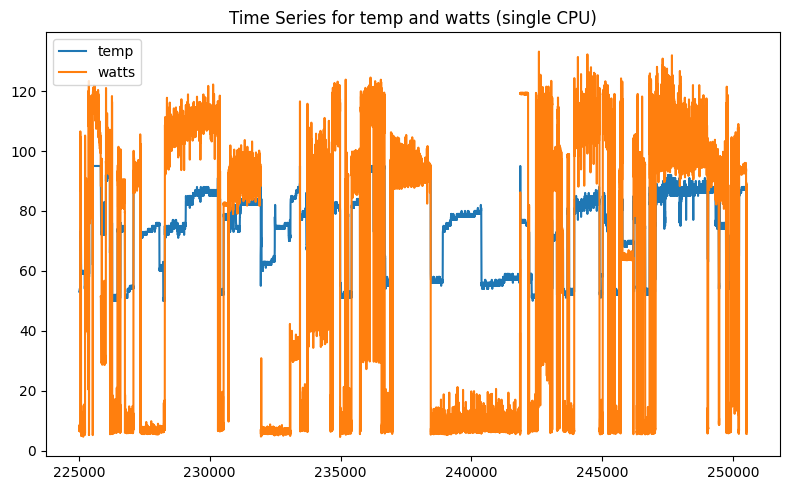

In [214]:
# time series plots for 'temp' and 'watts'
ax = singlecpu.plot(y='temp', figsize=(8, 5), grid=False, alpha=1.0)
singlecpu.plot(y='watts', ax=ax, grid=False, alpha=1.0)
ax.set_title('Time Series for temp and watts (single CPU)')
plt.tight_layout()
plt.show()

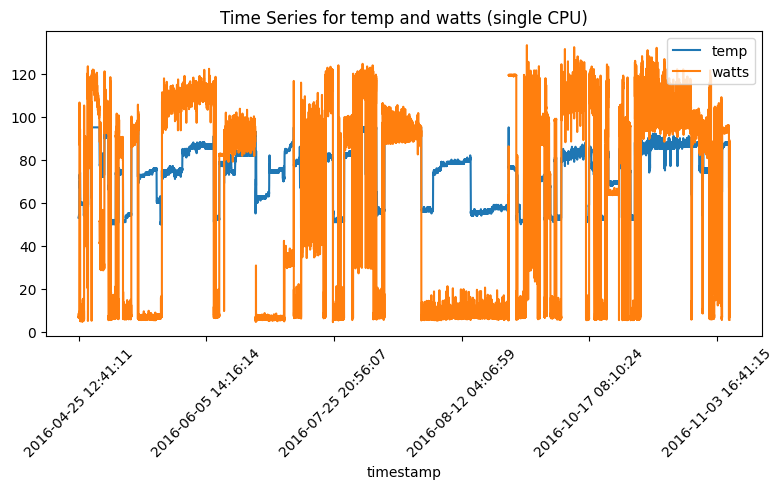

In [221]:
ax = singlecpu.sort_values('timestamp').plot(
    x='timestamp', y='temp',
    figsize=(8, 5), grid=False, alpha=1.0, rot=45
)
singlecpu.sort_values('timestamp').plot(
    x='timestamp', y='watts',
    ax=ax, grid=False, alpha=1.0, rot=45
)
ax.set_title('Time Series for temp and watts (single CPU)')
plt.tight_layout()
plt.show()

## Todo 
1) Create the two-dimensional scatterplot 'temp'(x-axis) vs. 'watts' (y-axis). 

Hint 1: Use the method 'plot.scatter' of the pandas dataframe class, see the docs at https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.scatter.html

Hint 2a: If necessary, enlarge the plot size by using the parameter 'figsize'.

Hint 2b: In order to handle overplotting use the parameter, e.g. 'alpha = 0.5'.

Hint 2c: For improving readability use the parameter 'grid = True'.

2) What measure(s) might be appropriate to characterize the dependency (if any) between temperature and power consumption? What is possible to conclude referring causation?

In [222]:
# two-dimensional scatterplot 'temp'(x-axis) vs. 'watts' (y-axis)
taurusdata['temp']

0         63
1         64
2         63
3         64
4         63
          ..
302847    49
302848    51
302849    49
302850    49
302851    50
Name: temp, Length: 302852, dtype: int64

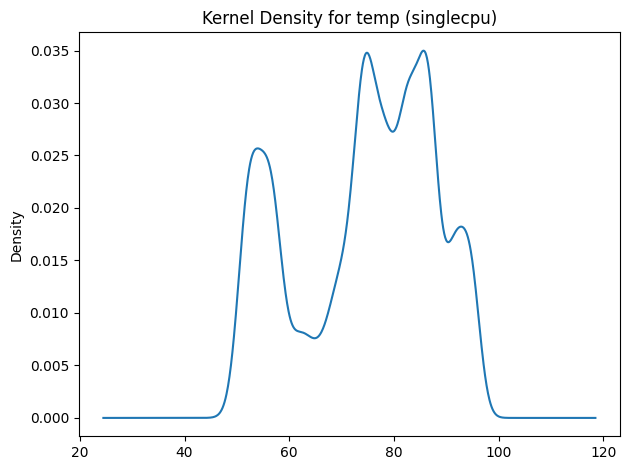

In [224]:
singlecpu['temp'].plot.kde()
plt.title('Kernel Density for temp (singlecpu)')
plt.tight_layout()
plt.show()

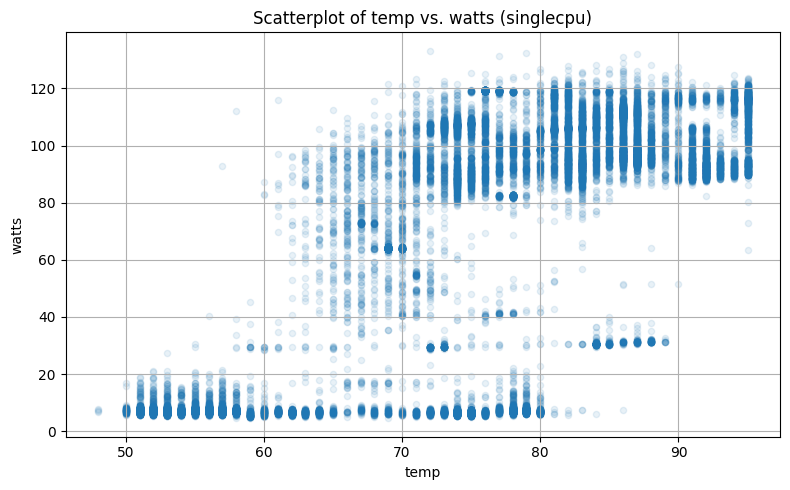

In [228]:
singlecpu.plot.scatter(x='temp', y='watts', alpha=0.1, figsize=(8, 5), grid=True)
plt.title('Scatterplot of temp vs. watts (singlecpu)')
plt.tight_layout()
plt.show()

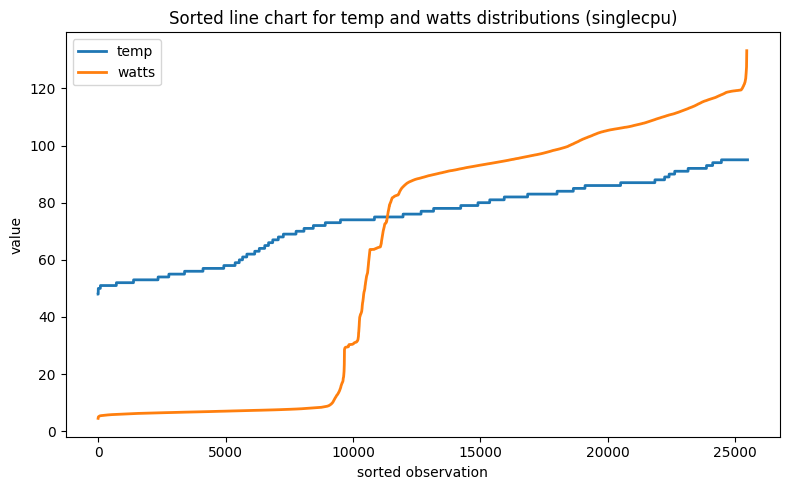

In [229]:
# line chart for the distribution of temp and watts
fig, ax = plt.subplots(figsize=(8, 5))
singlecpu['temp'].sort_values().reset_index(drop=True).plot(ax=ax, label='temp', linewidth=2)
singlecpu['watts'].sort_values().reset_index(drop=True).plot(ax=ax, label='watts', linewidth=2)
ax.set_title('Sorted line chart for temp and watts distributions (singlecpu)')
ax.set_xlabel('sorted observation')
ax.set_ylabel('value')
ax.legend()
plt.tight_layout()
plt.show()


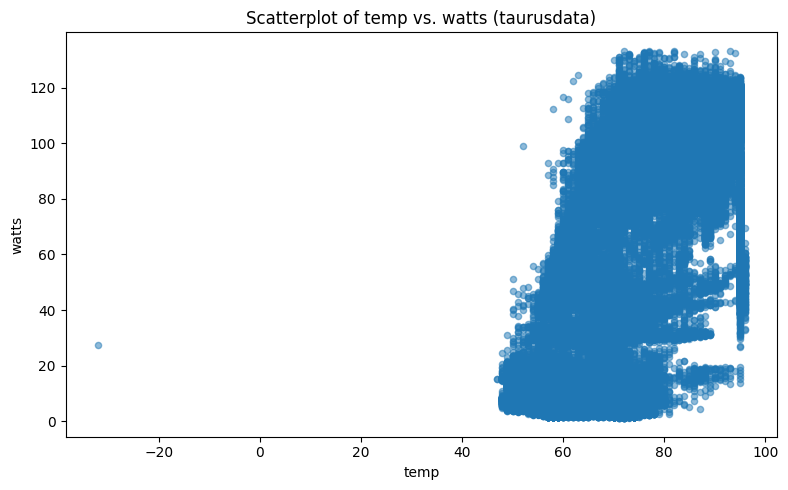

In [223]:
taurusdata.plot.scatter(x='temp', y='watts', alpha=0.5, figsize=(8, 5))
plt.title('Scatterplot of temp vs. watts (taurusdata)')
plt.tight_layout()
plt.show()

In [230]:
singlecpu.shape

(25487, 5)

In [235]:
singlecpu[singlecpu['watts'] < 60]

,node,cpu,timestamp,temp,watts
225026,taurusi6344,cpu1,2016-04-25 12:41:11,53,6.775252
225027,taurusi6344,cpu1,2016-04-25 12:41:15,53,6.624771
225028,taurusi6344,cpu1,2016-04-25 12:41:20,53,7.261403
225029,taurusi6344,cpu1,2016-04-25 12:41:25,53,8.562519
225030,taurusi6344,cpu1,2016-04-25 12:41:30,53,7.021208
...,...,...,...,...,...
250507,taurusi6344,cpu1,2016-11-05 08:38:39,66,6.840929
250508,taurusi6344,cpu1,2016-11-05 08:43:37,65,6.746433
250509,taurusi6344,cpu1,2016-11-05 08:48:36,79,29.492789
250510,taurusi6344,cpu1,2016-11-05 08:53:35,66,8.019001


In [234]:
singlecpu.describe()

,temp,watts
count,25487.000000,25457.000000
mean,74.649154,62.171613
std,13.081534,45.525440
min,48.000000,4.528585
25%,64.000000,7.363638
50%,77.000000,88.820081
75%,86.000000,102.456565
max,95.000000,133.179479


In [236]:
singlecpu[singlecpu['watts'] < 60]


,node,cpu,timestamp,temp,watts
225026,taurusi6344,cpu1,2016-04-25 12:41:11,53,6.775252
225027,taurusi6344,cpu1,2016-04-25 12:41:15,53,6.624771
225028,taurusi6344,cpu1,2016-04-25 12:41:20,53,7.261403
225029,taurusi6344,cpu1,2016-04-25 12:41:25,53,8.562519
225030,taurusi6344,cpu1,2016-04-25 12:41:30,53,7.021208
...,...,...,...,...,...
250507,taurusi6344,cpu1,2016-11-05 08:38:39,66,6.840929
250508,taurusi6344,cpu1,2016-11-05 08:43:37,65,6.746433
250509,taurusi6344,cpu1,2016-11-05 08:48:36,79,29.492789
250510,taurusi6344,cpu1,2016-11-05 08:53:35,66,8.019001


In [210]:
# characterizing dependency


# Analysis Part 2 -- Multiple Nodes
In this part of the analysis we will work with the data of several CPUs at the simultaneously. This means that each analysis step refers to all CPUs contained in the data set. Therefore, so-called grouping variables are needed. For the present data set, these are the variables 'node' and 'cpu'. When grouping by these two, each existing combination (node, cpu) in the data is taken into account and the analysis step is performed accordingly for each combination. 

## Todo
1) Calculate the basic descriptive statistics GROUPWISE, namely: mean, standard deviation, mininmum, maximum, all quartiles (i.e. quantiles with level 25%, 50%, 75%). 

Hint 1: Use the method 'groupby' of pandas dataframe for groupwise consideration, see the docs at https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html

Hint 2: Use the method 'describe' of pandas dataframe, see the docs at https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html

2) Do you see some indication for extreme values? Explain your observation with statistical measures!

In [240]:
# basic descriptive statistics GROUPWISE
taurusdata.groupby(['cpu']).describe()

temp                                                         watts  \
         count       mean        std   min   25%   50%   75%   max     count   
cpu                                                                            
cpu0  151608.0  67.823209  13.073509 -32.0  56.0  67.0  76.0  96.0  151265.0   
cpu1  151244.0  68.327471  13.356475  48.0  56.0  68.0  78.0  96.0  150909.0   

                                                                       \
           mean        std       min        25%        50%        75%   
cpu                                                                     
cpu0  52.446165  40.396301  7.509039  14.163039  40.089934  94.554421   
cpu1  47.741414  42.995508  1.074336   6.674995  29.457984  92.279038   

                  
             max  
cpu               
cpu0  132.871383  
cpu1  133.249055

In [243]:
taurusdata.groupby('node')[['temp','watts']].describe().style.background_gradient(cmap='viridis')

In [245]:
taurusdata.groupby(['cpu', 'node']).describe().style.background_gradient(cmap='viridis')

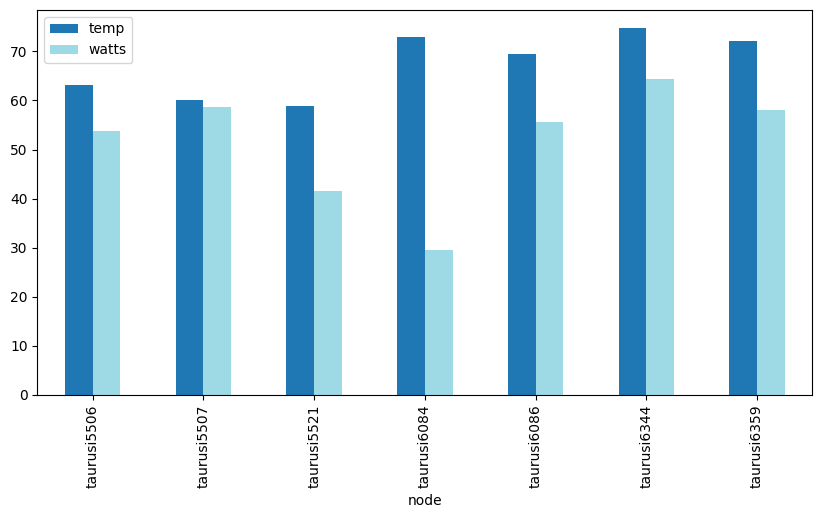

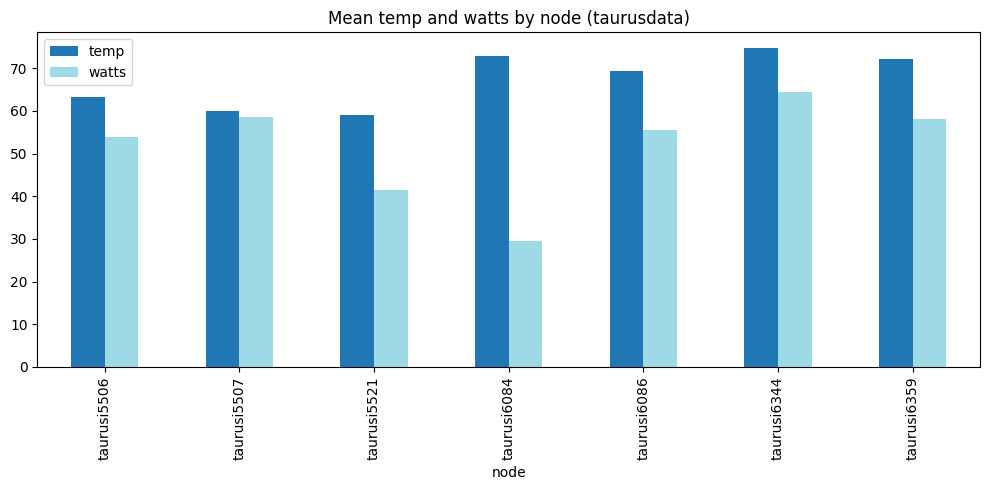

In [242]:
taurusdata.groupby('node')[['temp','watts']].mean().plot(kind='bar', figsize=(10,5), colormap='tab20')
plt.title('Mean temp and watts by node (taurusdata)')
plt.tight_layout()
plt.show()

## Todo
1) Calculate the boxplots groupwise.

Hint: Grouping is not necessary as the method 'boxplot' has the parameter 'by'.

2) Do you see some indication for extreme values? Explain your observation with statistical measures!

In [259]:
taurusdata[['temp', 'watts']].corr().style.background_gradient(cmap='autumn')

,temp,watts
temp,1.000000,0.727026
watts,0.727026,1.000000


In [260]:
for key, group in taurusdata.groupby('node'):
    print(f"Node: {key}")
    print(group[['temp', 'watts']].corr())
    print("\n")

Node: taurusi5506
           temp     watts
temp   1.000000  0.776613
watts  0.776613  1.000000


Node: taurusi5507
           temp     watts
temp   1.000000  0.988944
watts  0.988944  1.000000


Node: taurusi5521
           temp     watts
temp   1.000000  0.949451
watts  0.949451  1.000000


Node: taurusi6084
           temp     watts
temp   1.000000  0.835777
watts  0.835777  1.000000


Node: taurusi6086
           temp     watts
temp   1.000000  0.856351
watts  0.856351  1.000000


Node: taurusi6344
           temp     watts
temp   1.000000  0.763423
watts  0.763423  1.000000


Node: taurusi6359
           temp     watts
temp   1.000000  0.930923
watts  0.930923  1.000000




In [261]:
taurusdata.groupby(['cpu', 'node']).groups

{('cpu0', 'taurusi5507'): RangeIndex(start=177900, stop=207500, step=1),
 ('cpu0', 'taurusi5521'): RangeIndex(start=250513, stop=276685, step=1),
 ('cpu0', 'taurusi6084'): RangeIndex(start=95564, stop=125078, step=1),
 ('cpu0', 'taurusi6086'): RangeIndex(start=0, stop=17527, step=1),
 ('cpu0', 'taurusi6344'): RangeIndex(start=17527, stop=43013, step=1),
 ('cpu0', 'taurusi6359'): RangeIndex(start=43013, stop=66322, step=1),
 ('cpu1', 'taurusi5506'): RangeIndex(start=66322, stop=95564, step=1),
 ('cpu1', 'taurusi5521'): RangeIndex(start=276685, stop=302852, step=1),
 ('cpu1', 'taurusi6084'): RangeIndex(start=125078, stop=154591, step=1),
 ('cpu1', 'taurusi6086'): RangeIndex(start=207500, stop=225026, step=1),
 ('cpu1', 'taurusi6344'): RangeIndex(start=225026, stop=250513, step=1),
 ('cpu1', 'taurusi6359'): RangeIndex(start=154591, stop=177900, step=1)}

Node: ('taurusi5506', 'cpu1')



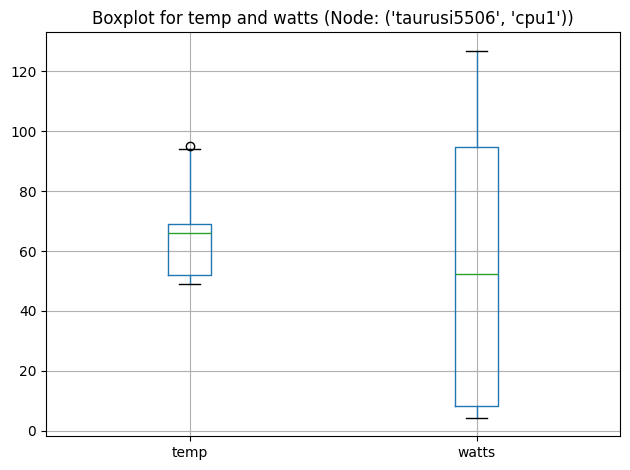



Node: ('taurusi5507', 'cpu0')



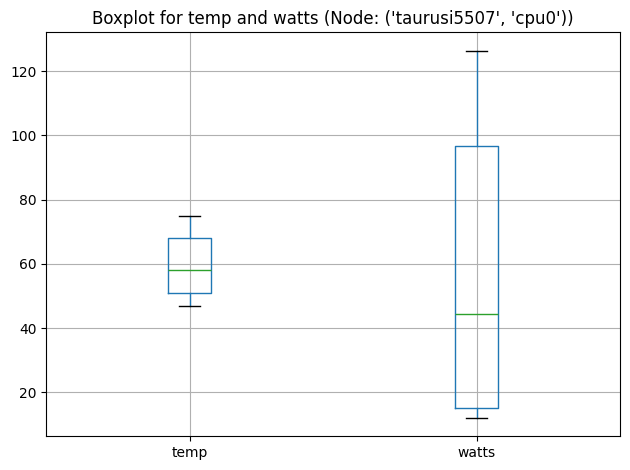



Node: ('taurusi5521', 'cpu0')



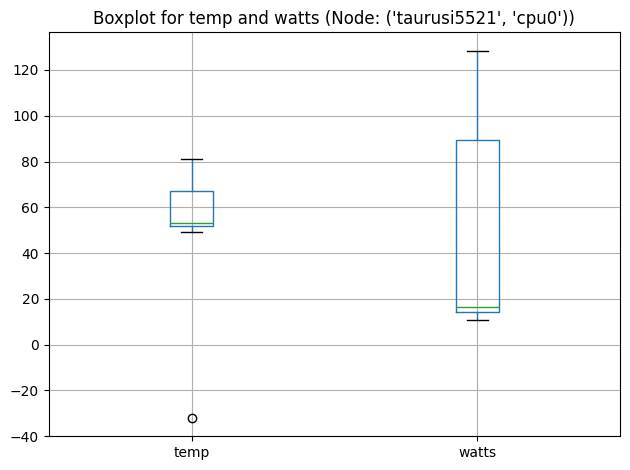



Node: ('taurusi5521', 'cpu1')



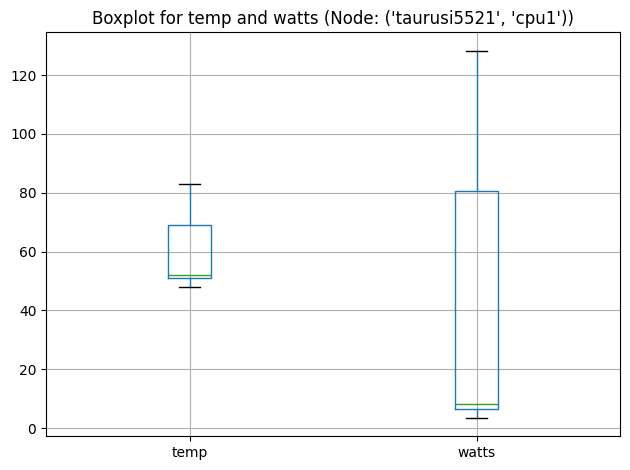



Node: ('taurusi6084', 'cpu0')



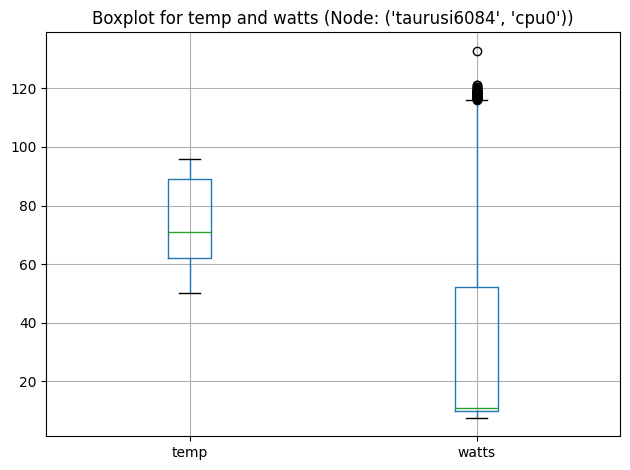



Node: ('taurusi6084', 'cpu1')



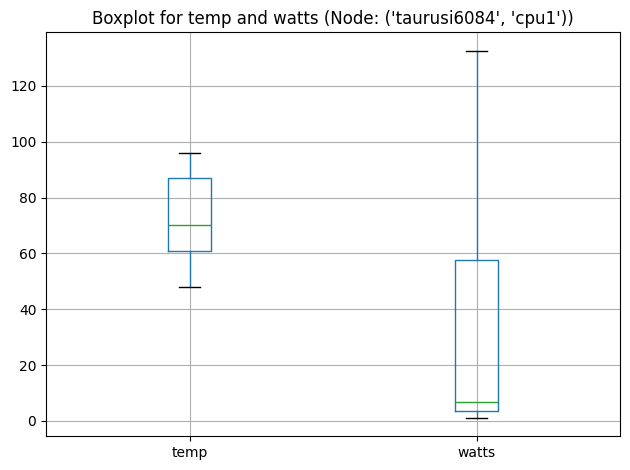



Node: ('taurusi6086', 'cpu0')



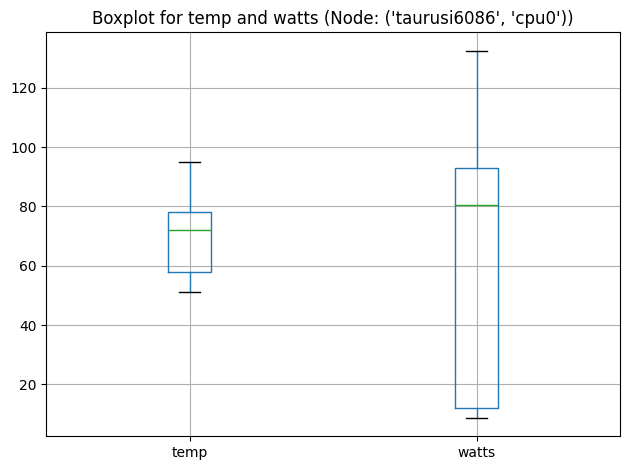



Node: ('taurusi6086', 'cpu1')



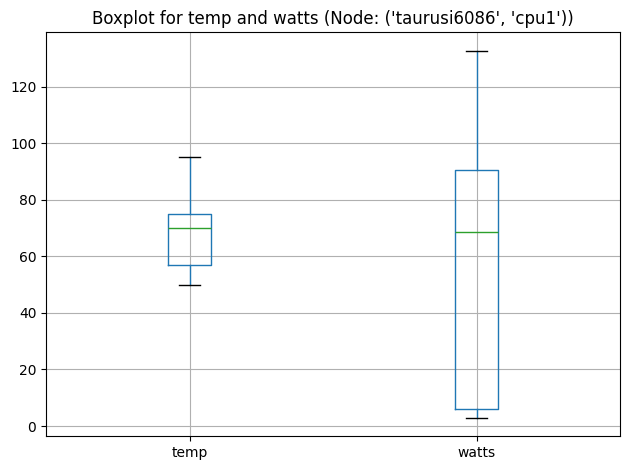



Node: ('taurusi6344', 'cpu0')



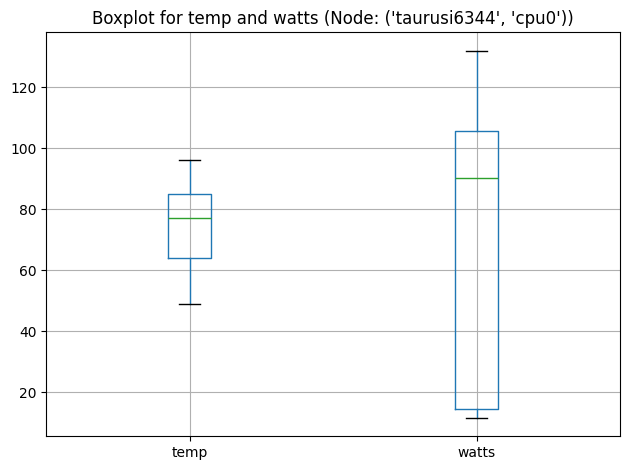



Node: ('taurusi6344', 'cpu1')



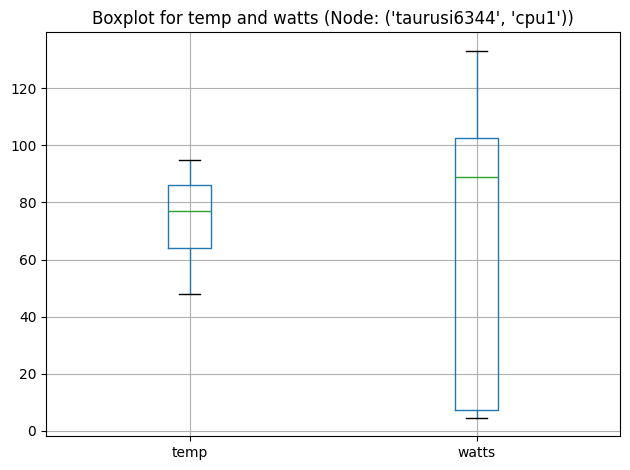



Node: ('taurusi6359', 'cpu0')



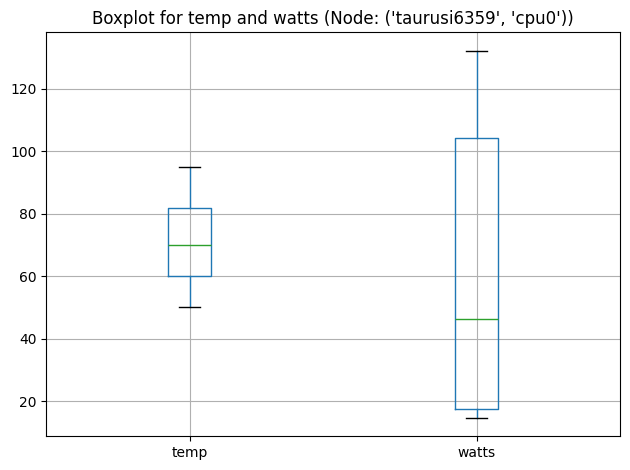



Node: ('taurusi6359', 'cpu1')



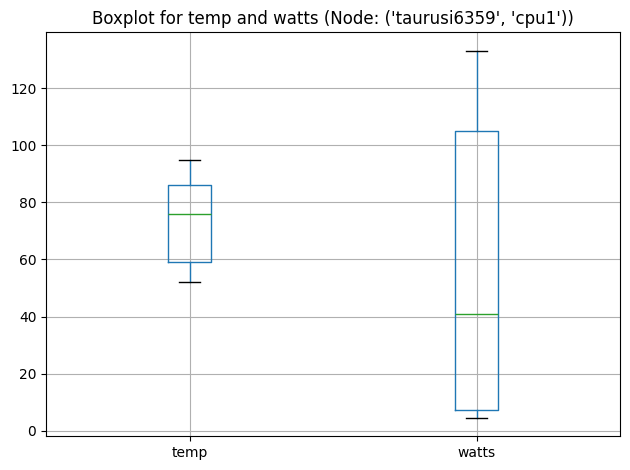

In [266]:
for key, idx in taurusdata.groupby(['node', 'cpu']).groups.items():
    print(f"Node: {key}\n")
    taurusdata.loc[idx, ['temp', 'watts']].boxplot()
    plt.title(f"Boxplot for temp and watts (Node: {key})")
    plt.tight_layout()
    plt.show()
    print("\n")

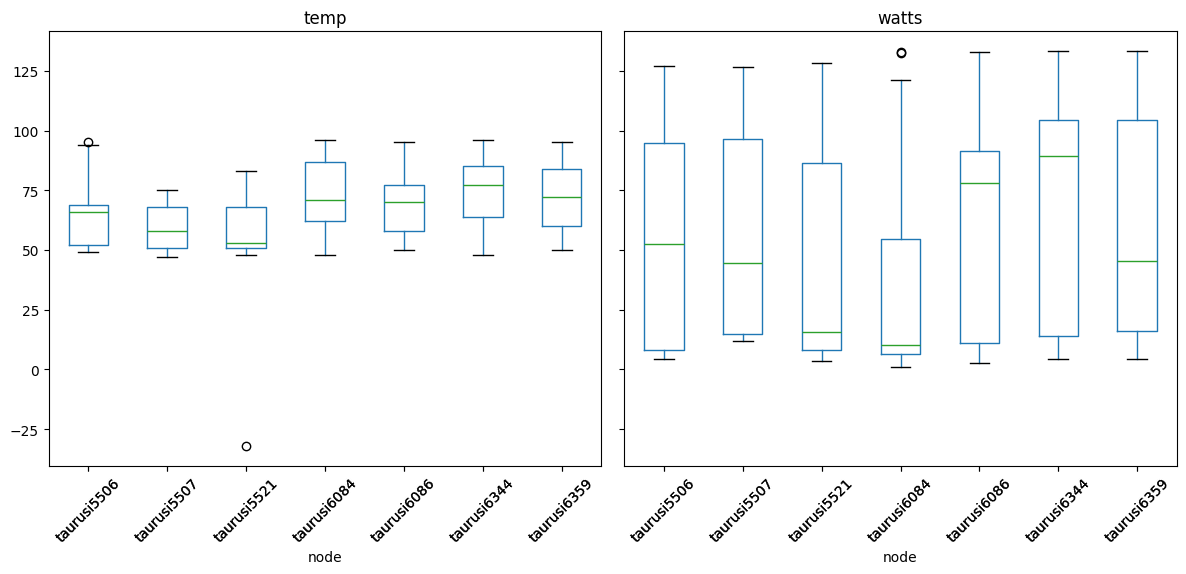

In [250]:
ax = taurusdata.boxplot(column=['temp', 'watts'], by='node', figsize=(12, 6), grid=False, rot=45)
plt.suptitle('')
plt.tight_layout()
plt.show()

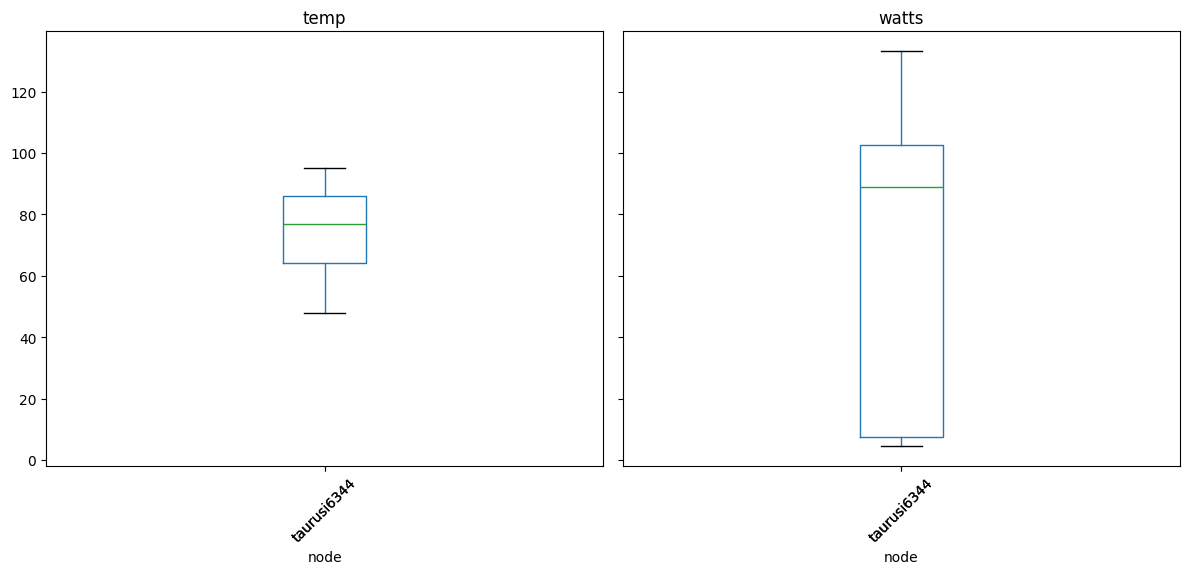

In [255]:
# boxplots groupwise
ax = singlecpu.boxplot(column=['temp', 'watts'], by='node', figsize=(12, 6), grid=False, rot=45)
plt.suptitle('')
plt.tight_layout()
plt.show()

## Todo
1) Calculate the correlation between 'temp' and 'watts' groupwise.

2) Do you see some indication for extreme values? Explain your observation with statistical measures! Check for consistency of your indications with the groupwise boxplots from above!

In [ ]:
# correlation between 'temp' and 'watts' groupwise
